# Evaluation CNN per FER-2013

Questo notebook valuta un modello salvato in `experiments/`.
Di default seleziona l'esperimento completo piu' recente, ma si puo' impostare manualmente `EXPERIMENT_NAME`.

Le figure, le tabelle e le predizioni vengono esportate in `results/`.


In [1]:
from pathlib import Path
from time import perf_counter
from datetime import datetime
from contextlib import contextmanager
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def log_step(message):
    now = datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] {message}", flush=True)


@contextmanager
def timed_step(name):
    start_time = perf_counter()
    log_step(f"INIZIO - {name}")
    try:
        yield
    finally:
        elapsed = perf_counter() - start_time
        log_step(f"FINE - {name} ({elapsed:.1f}s)")


SEED = 42
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 32

log_step(f"TensorFlow: {tf.__version__}")
log_step(f"GPU disponibili: {tf.config.list_physical_devices('GPU')}")


[00:08:24] TensorFlow: 2.21.0
[00:08:24] GPU disponibili: []


In [2]:
with timed_step("Configurazione percorsi evaluation"):
    current_dir = Path.cwd()
    project_root = current_dir if (current_dir / "data").exists() else current_dir.parent

    experiments_root = project_root / "experiments"
    results_root = project_root / "results"

    # Imposta il nome di una cartella specifica, ad esempio:
    # EXPERIMENT_NAME = "20260627_180349_cnn_v1"
    EXPERIMENT_NAME = "20260706_233427_cnn_v4"

    if EXPERIMENT_NAME:
        run_day = f"{EXPERIMENT_NAME[:4]}-{EXPERIMENT_NAME[4:6]}-{EXPERIMENT_NAME[6:8]}"
        experiment_dir = experiments_root / run_day / EXPERIMENT_NAME
    else:
        complete_experiments = sorted(
            [
                p for p in experiments_root.glob("*/*")
                if p.is_dir()
                and (p / "model.keras").exists()
                and (p / "training_history.csv").exists()
                and (p / "test_results.txt").exists()
            ],
            key=lambda p: p.name,
            reverse=True,
        )
        if not complete_experiments:
            raise FileNotFoundError(
                f"Nessun esperimento completo trovato in {experiments_root}. "
                "Esegui prima notebooks/Training.ipynb."
            )
        experiment_dir = complete_experiments[0]

    experiment_name = experiment_dir.name
    run_day = f"{experiment_name[:4]}-{experiment_name[4:6]}-{experiment_name[6:8]}"
    results_run_dir = results_root / run_day / experiment_name
    results_figures_dir = results_run_dir / "figures"
    results_tables_dir = results_run_dir / "tables"
    results_predictions_dir = results_run_dir / "predictions"
    for output_dir in [results_figures_dir, results_tables_dir, results_predictions_dir]:
        output_dir.mkdir(parents=True, exist_ok=True)

    model_path = experiment_dir / "model.keras"
    test_dir = project_root / "data" / "original" / "test"

    if not model_path.exists():
        raise FileNotFoundError(f"Modello non trovato: {model_path}.")
    if not test_dir.exists():
        raise FileNotFoundError(f"Cartella test non trovata: {test_dir}")

    log_step(f"Project root: {project_root}")
    log_step(f"Experiment directory: {experiment_dir}")
    log_step(f"Model path: {model_path}")
    log_step(f"Test directory: {test_dir}")


[00:08:25] INIZIO - Configurazione percorsi evaluation
[00:08:25] Project root: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward
[00:08:25] Experiment directory: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\experiments\2026-07-06\20260706_233427_cnn_v4
[00:08:25] Model path: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\experiments\2026-07-06\20260706_233427_cnn_v4\model.keras
[00:08:25] Test directory: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\data\original\test
[00:08:25] FINE - Configurazione percorsi evaluation (0.0s)


In [3]:
with timed_step("Caricamento modello e test generator"):
    model = load_model(model_path)

    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="grayscale",
        class_mode="categorical",
        shuffle=False
    )

    emotion_labels = {v: k for k, v in test_generator.class_indices.items()}

    log_step(f"Test samples: {test_generator.samples}")
    log_step(f"Batch di test: {len(test_generator)}")
    log_step(f"Classi: {test_generator.class_indices}")


[00:08:28] INIZIO - Caricamento modello e test generator
Found 7178 images belonging to 7 classes.
[00:08:28] Test samples: 7178
[00:08:28] Batch di test: 225
[00:08:28] Classi: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
[00:08:28] FINE - Caricamento modello e test generator (0.5s)


In [4]:
with timed_step("Valutazione modello salvato"):
    log_step("Eseguo model.evaluate")
    test_loss, test_accuracy, test_auc = model.evaluate(test_generator, verbose=1)

    log_step(f"Test loss: {test_loss:.4f}")
    log_step(f"Test accuracy: {test_accuracy:.4f}")
    log_step(f"Test AUC: {test_auc:.4f}")


[00:08:30] INIZIO - Valutazione modello salvato
[00:08:30] Eseguo model.evaluate
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5315 - auc: 0.8716 - loss: 1.2193
[00:08:34] Test loss: 1.2193
[00:08:34] Test accuracy: 0.5315
[00:08:34] Test AUC: 0.8716
[00:08:34] FINE - Valutazione modello salvato (3.6s)


[00:08:36] INIZIO - Predizioni e report
[00:08:36] Calcolo predizioni sul test set
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
[00:08:39] Classification report
              precision    recall  f1-score   support

       angry       0.47      0.37      0.41       958
     disgust       0.25      0.74      0.38       111
        fear       0.41      0.16      0.23      1024
       happy       0.79      0.76      0.77      1774
     neutral       0.44      0.58      0.50      1233
         sad       0.39      0.43      0.41      1247
    surprise       0.64      0.74      0.69       831

    accuracy                           0.53      7178
   macro avg       0.48      0.54      0.48      7178
weighted avg       0.53      0.53      0.52      7178

[00:08:39] Confusion matrix
[[ 352   75   54   55  163  218   41]
 [  15   82    1    2    3    6    2]
 [ 119   47  164   69  220  240  165]
 [  57   17   32 1354  136  112   66]
 [  66   38   42   96  714  249   28]
 [ 122   60   51  101  336 

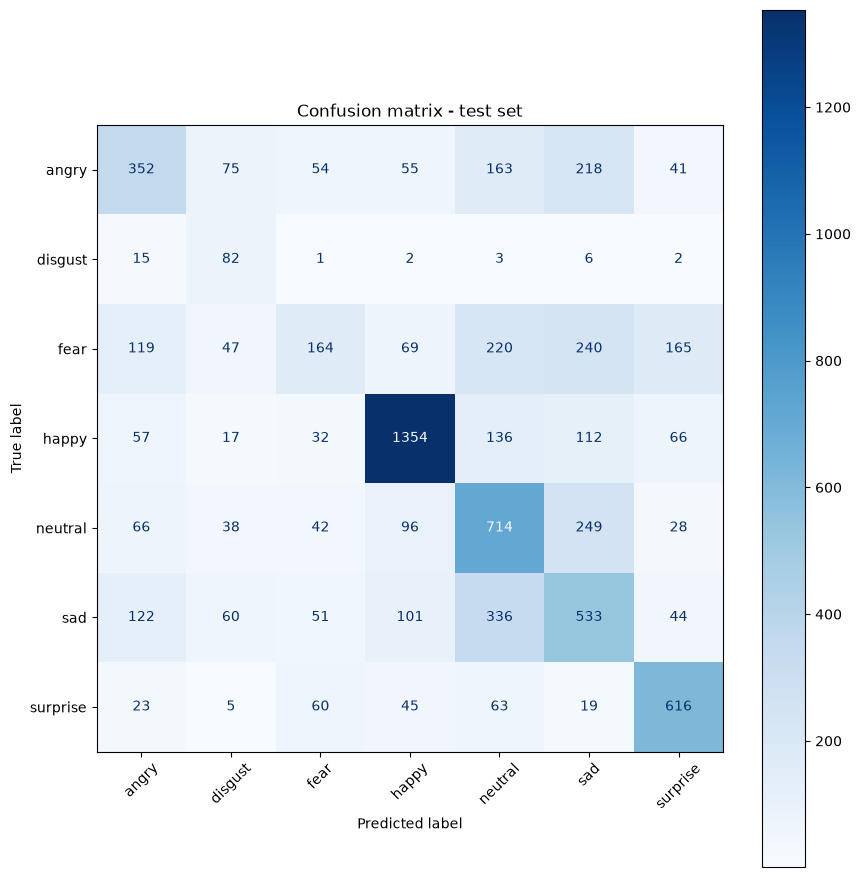

[00:08:40] Classification report CSV salvato in: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\results\2026-07-06\20260706_233427_cnn_v4\tables\20260706_233427_cnn_v4_classification_report.csv
[00:08:40] Confusion matrix CSV salvata in: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\results\2026-07-06\20260706_233427_cnn_v4\tables\20260706_233427_cnn_v4_confusion_matrix.csv
[00:08:40] Predizioni test salvate in: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\results\2026-07-06\20260706_233427_cnn_v4\predictions\20260706_233427_cnn_v4_test_predictions.csv
[00:08:40] Confusion matrix PNG salvata in: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\results\2026-07-06\20260706_233427_cnn_v4\figures\20260706_233427_cnn_v4_confusion_matrix.png
[00:08:40] FINE - Predizioni e report (3.6s)


In [5]:
import pandas as pd

with timed_step("Predizioni e report"):
    log_step("Calcolo predizioni sul test set")
    y_true = test_generator.classes
    y_pred_proba = model.predict(test_generator, verbose=1)
    y_pred = np.argmax(y_pred_proba, axis=1)

    target_names = [emotion_labels[i] for i in range(len(emotion_labels))]

    log_step("Classification report")
    class_report = classification_report(y_true, y_pred, target_names=target_names)
    class_report_dict = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True,
    )
    print(class_report)

    log_step("Confusion matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    experiment_name = experiment_dir.name
    report_csv_path = results_tables_dir / f"{experiment_name}_classification_report.csv"
    confusion_csv_path = results_tables_dir / f"{experiment_name}_confusion_matrix.csv"
    predictions_csv_path = results_predictions_dir / f"{experiment_name}_test_predictions.csv"
    confusion_fig_path = results_figures_dir / f"{experiment_name}_confusion_matrix.png"

    pd.DataFrame(class_report_dict).transpose().to_csv(report_csv_path)
    pd.DataFrame(cm, index=target_names, columns=target_names).to_csv(confusion_csv_path)

    predictions_df = pd.DataFrame(
        {
            "filepath": test_generator.filepaths,
            "true_label": [target_names[i] for i in y_true],
            "predicted_label": [target_names[i] for i in y_pred],
        }
    )
    for class_index, class_name in enumerate(target_names):
        predictions_df[f"prob_{class_name}"] = y_pred_proba[:, class_index]
    predictions_df.to_csv(predictions_csv_path, index=False)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    fig, ax = plt.subplots(figsize=(9, 9))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    plt.title("Confusion matrix - test set")
    plt.tight_layout()
    fig.savefig(confusion_fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    log_step(f"Classification report CSV salvato in: {report_csv_path}")
    log_step(f"Confusion matrix CSV salvata in: {confusion_csv_path}")
    log_step(f"Predizioni test salvate in: {predictions_csv_path}")
    log_step(f"Confusion matrix PNG salvata in: {confusion_fig_path}")


# GradCam

Utilizza l'ispezione dinamica per capire la topologia del modello, estrae la porzione corretta tramite le API funzionali di Keras, elabora l'input in modo dinamico e cicla su tutti i tuoi esperimenti

### Inizializzazione path e funzioni di supporto

In [6]:
import os
import cv2
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE PERCORSI ---
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "data").exists() else CURRENT_DIR.parent
PATH_EXPERIMENTS = str(PROJECT_ROOT / "experiments")
PATH_ORIGINALI_BASE = str(PROJECT_ROOT / "data" / "original")
PATH_PROCESSATE_BASE = str(PROJECT_ROOT / "data" / "processed")
PATH_OUTPUT_PLOT = str(PROJECT_ROOT / "gradcam_results")

os.makedirs(PATH_OUTPUT_PLOT, exist_ok=True)

# --- CHIAVI DI RICERCA PER L'IMMAGINE DA USARE ---
CLASSI = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
NOME_CLASSE = "happy"
NOME_FILE = "Training_11204.jpg"

# --- 1. RICERCA E CARICAMENTO DELLE IMMAGINI ---
def trova_percorso_file(percorso_base, nome_classe, nome_file):
    for root, dirs, files in os.walk(percorso_base):
        if os.path.basename(root) == nome_classe and nome_file in files:
            return os.path.join(root, nome_file)
    return None

path_originale = trova_percorso_file(PATH_ORIGINALI_BASE, NOME_CLASSE, NOME_FILE)
path_processata = trova_percorso_file(PATH_PROCESSATE_BASE, NOME_CLASSE, NOME_FILE)

if not path_originale or not path_processata:
    raise FileNotFoundError("Impossibile trovare l'immagine specificata in uno dei due rami.")

# Caricamento e preparazione delle immagini base
img_originale = cv2.imread(path_originale)
img_originale_rgb = cv2.cvtColor(img_originale, cv2.COLOR_BGR2RGB)
altezza_orig, larghezza_orig = img_originale_rgb.shape[:2]

img_proc = cv2.imread(path_processata, cv2.IMREAD_GRAYSCALE)
img_proc_input = img_proc.astype("float32") / 255.0
img_proc_input = np.expand_dims(np.expand_dims(img_proc_input, axis=-1), axis=0)


# --- 2. FUNZIONE GRAD-CAM UNIVERSALE (INTEGRAZIONE NATIVA TAPE) ---
def get_gradcam_heatmap(img_tensor, model, target_layer_name, is_nested, nested_layer):
    """
    Genera la heatmap Grad-CAM in modo nativo estraendo i sotto-componenti del grafo.
    Risolve il problema dei modelli Sequential usando un approccio di forward pass esplicito
    sotto GradientTape quando necessario.
    """
    # Identifichiamo i layer di classificazione custom aggiunti in coda al modello principale
    gap_layer, dropout_layer, dense_layer = None, None, None
    
    for layer in model.layers:
        if "global_average_pooling2d" in layer.name or "global_pooling" in layer.name:
            gap_layer = layer
        elif "dropout" in layer.name:
            dropout_layer = layer
        elif "dense" in layer.name:
            dense_layer = layer

    # CASO A: Il modello ha una struttura annidata (es. MobileNetV2 Transfer Learning)
    if is_nested:
        base_grad_model = tf.keras.models.Model(
            nested_layer.inputs, 
            nested_layer.get_layer(target_layer_name).output
        )
        
        with tf.GradientTape() as tape:
            last_conv_layer_output = base_grad_model(img_tensor)
            x = last_conv_layer_output
            if gap_layer and dropout_layer and dense_layer:
                x = gap_layer(x)
                x = dropout_layer(x, training=False)
                preds = dense_layer(x)
            else:
                preds = model(img_tensor)
                
            class_index = tf.argmax(preds[0])
            class_channel = preds[:, class_index]
            
    # CASO B: Il modello è una CNN flat/sequenziale costruita da zero
    else:
        # Se il modello è un Sequential puro (o contiene un blocco Sequential non inizializzato),
        # l'estrazione funzionale standard fallisce. Ricostruiamo il flusso layer per layer sotto il Tape.
        with tf.GradientTape() as tape:
            x = img_tensor
            last_conv_layer_output = None
            
            # Scorriamo i layer uno alla volta calcolando gli output dinamici
            for layer in model.layers:
                # Gestione dei layer di BatchNormalization o Dropout se presenti nelle tue CNN
                if isinstance(layer, (keras.layers.BatchNormalization, keras.layers.Dropout)):
                    x = layer(x, training=False)
                else:
                    x = layer(x)
                
                # Intercettiamo lo strato target
                if layer.name == target_layer_name:
                    last_conv_layer_output = x
            
            preds = x
            class_index = tf.argmax(preds[0])
            class_channel = preds[:, class_index]
            
        if last_conv_layer_output is None:
            raise ValueError(f"Impossibile intercettare l'output del layer: {target_layer_name}")

    # Calcolo dei gradienti comune a entrambi i rami
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalizzazione ReLU nativa
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy(), class_index.numpy()

### Cicla su tutti i modelli salvati


[ELABORAZIONE] Elaboro il modello: 20260628_120337_cnn_v1

 -> Layer selezionato per Grad-CAM: 'conv2d_3' (Nidificato: False)


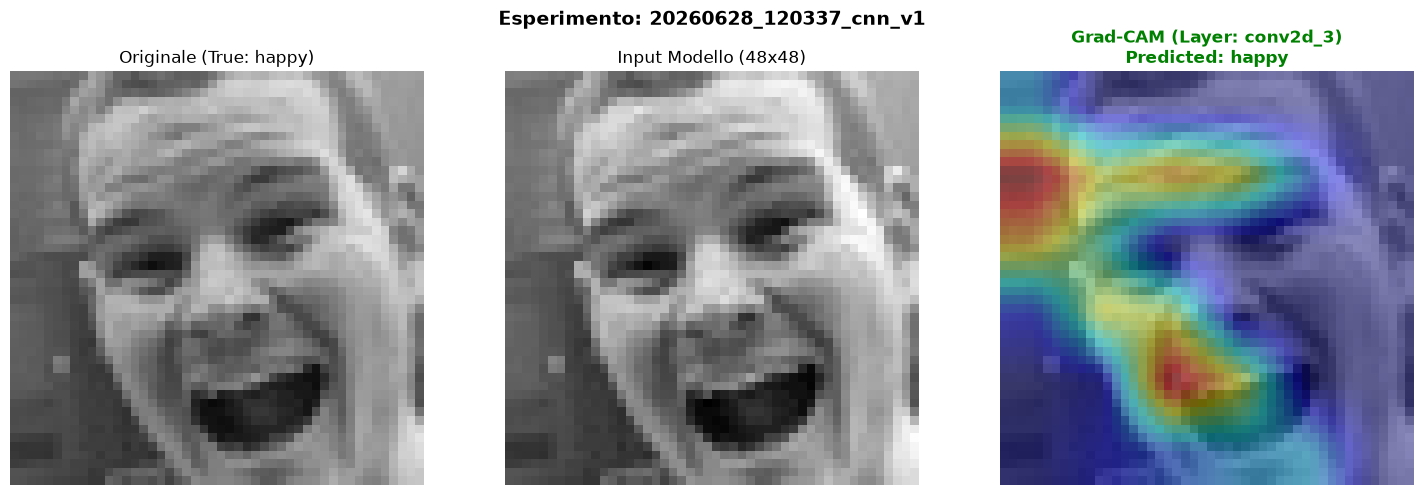


[ELABORAZIONE] Elaboro il modello: 20260628_124858_mobilenetv2_transfer
 -> Layer selezionato per Grad-CAM: 'out_relu' (Nidificato: True)


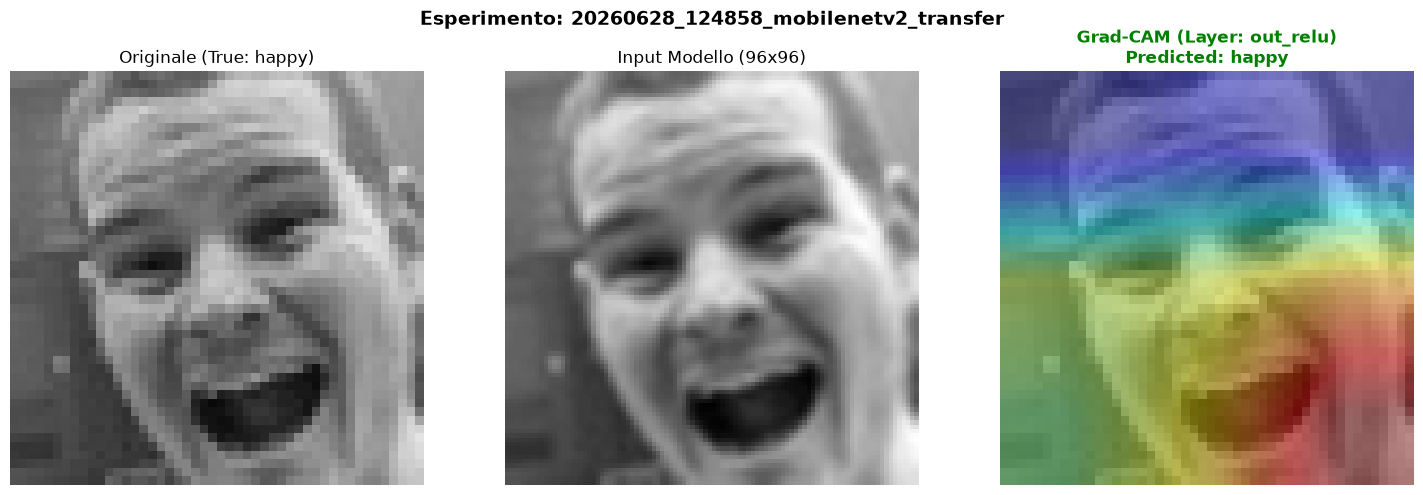


[ELABORAZIONE] Elaboro il modello: 20260628_181653_mobilenetv2_transfer
 -> Layer selezionato per Grad-CAM: 'out_relu' (Nidificato: True)


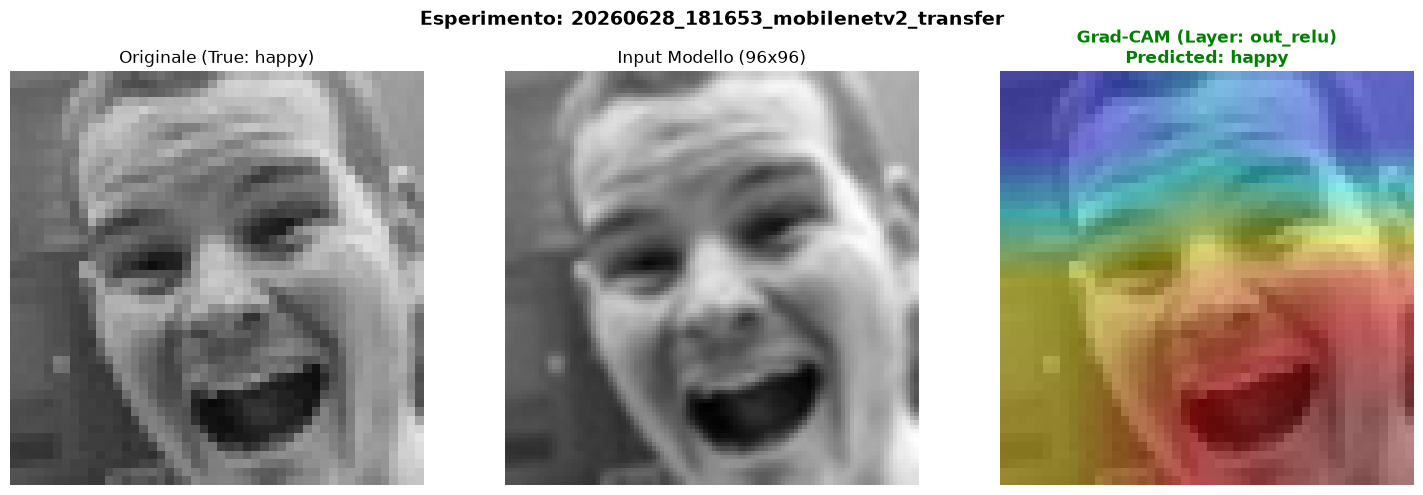


[ELABORAZIONE] Elaboro il modello: 20260629_095652_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_11' (Nidificato: False)


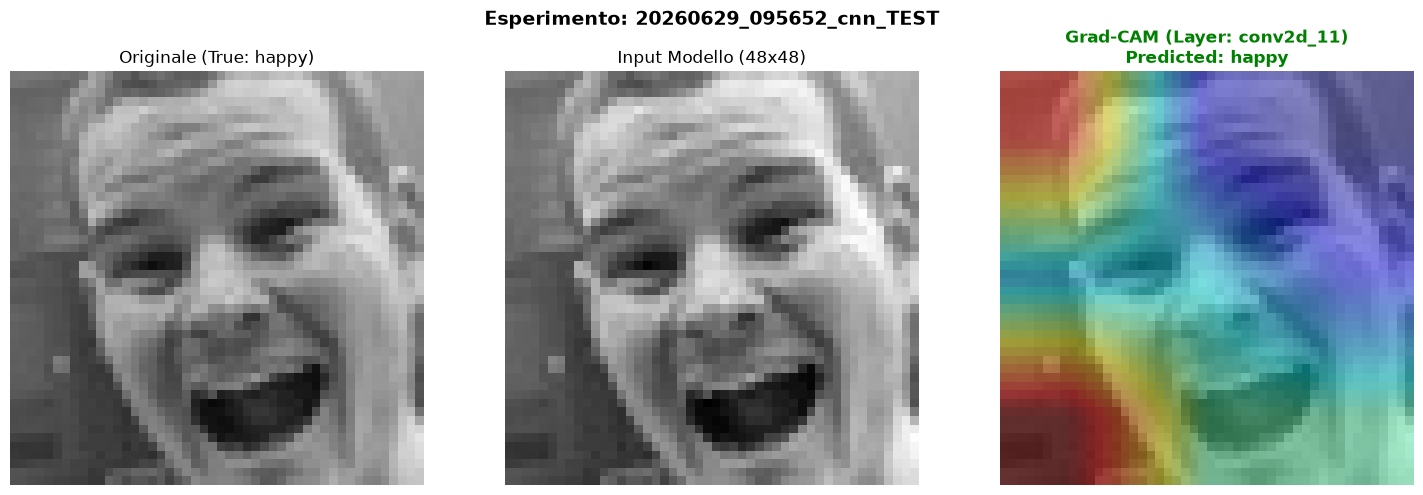


[ELABORAZIONE] Elaboro il modello: 20260629_102412_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_21' (Nidificato: False)


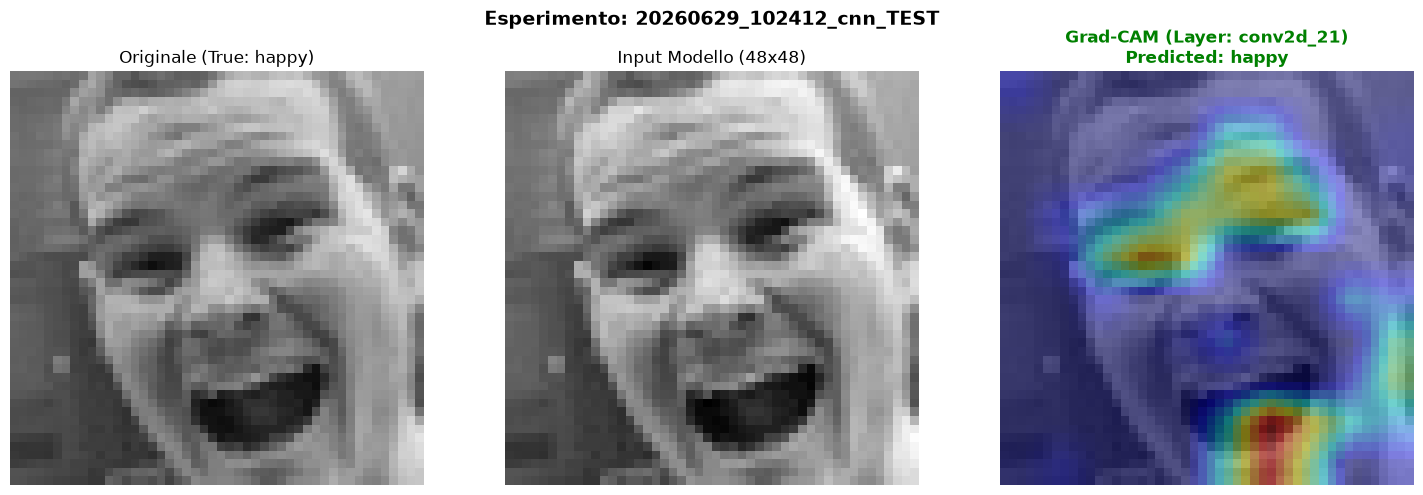


[ELABORAZIONE] Elaboro il modello: 20260629_111927_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_27' (Nidificato: False)


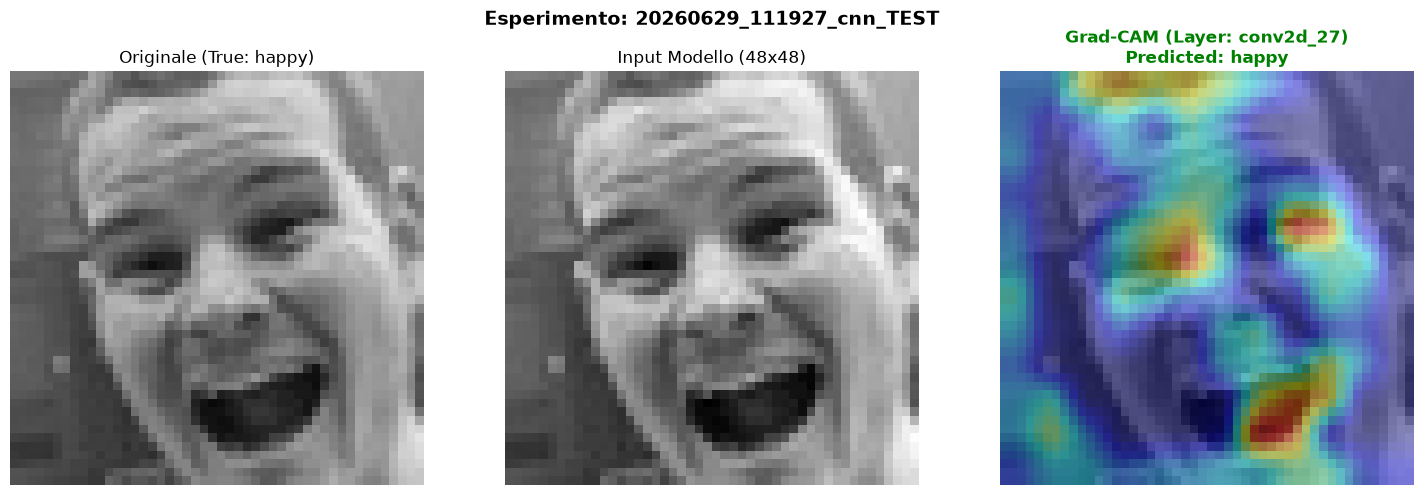


[ELABORAZIONE] Elaboro il modello: 20260629_154037_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_2' (Nidificato: False)


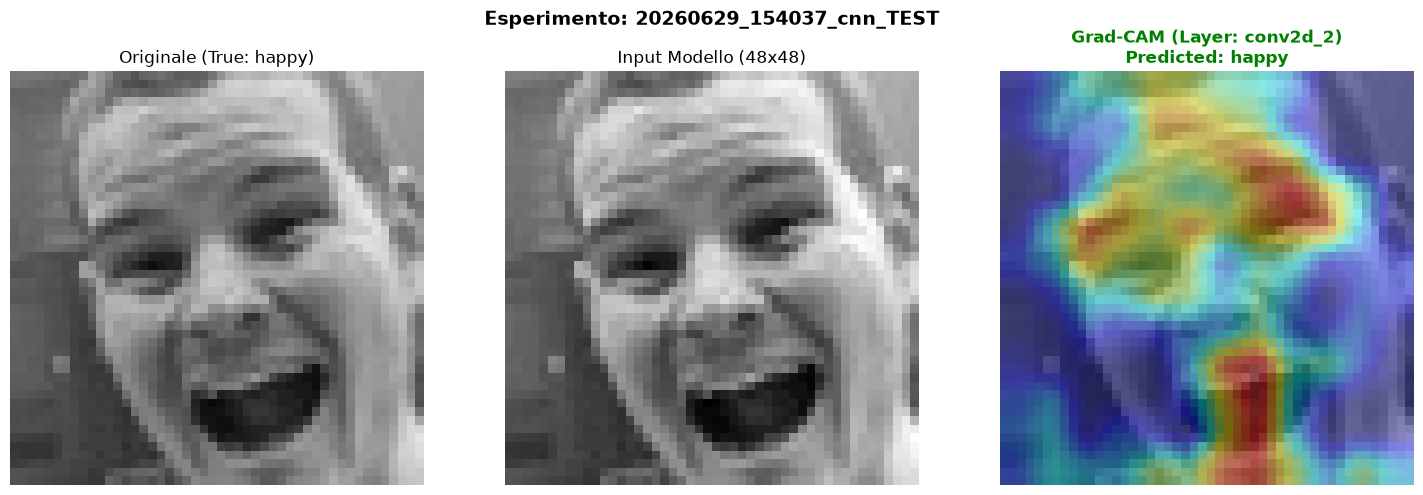


[ELABORAZIONE] Elaboro il modello: 20260629_162808_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_5' (Nidificato: False)


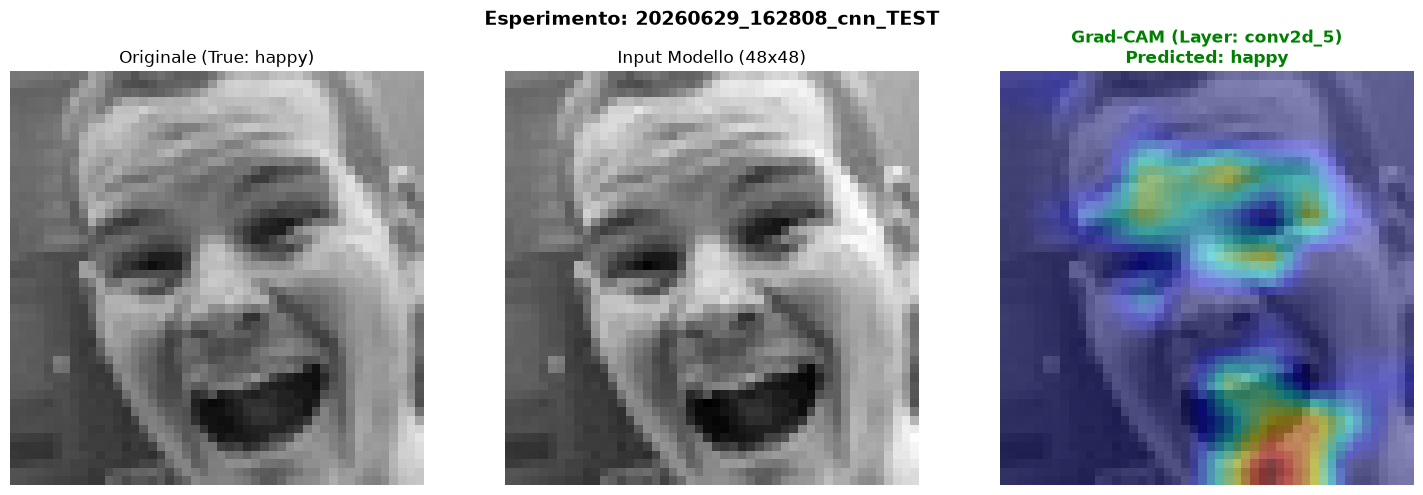


[ELABORAZIONE] Elaboro il modello: 20260629_170920_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_11' (Nidificato: False)


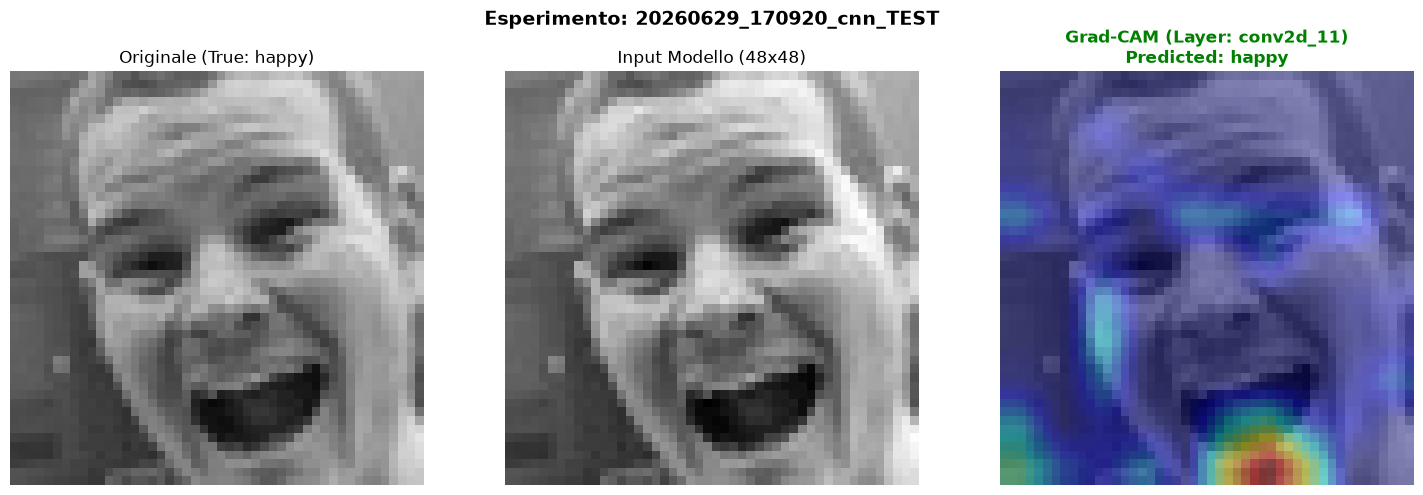


[ELABORAZIONE] Elaboro il modello: 20260629_185100_cnn_complex_v1
 -> Layer selezionato per Grad-CAM: 'conv2d_9' (Nidificato: False)


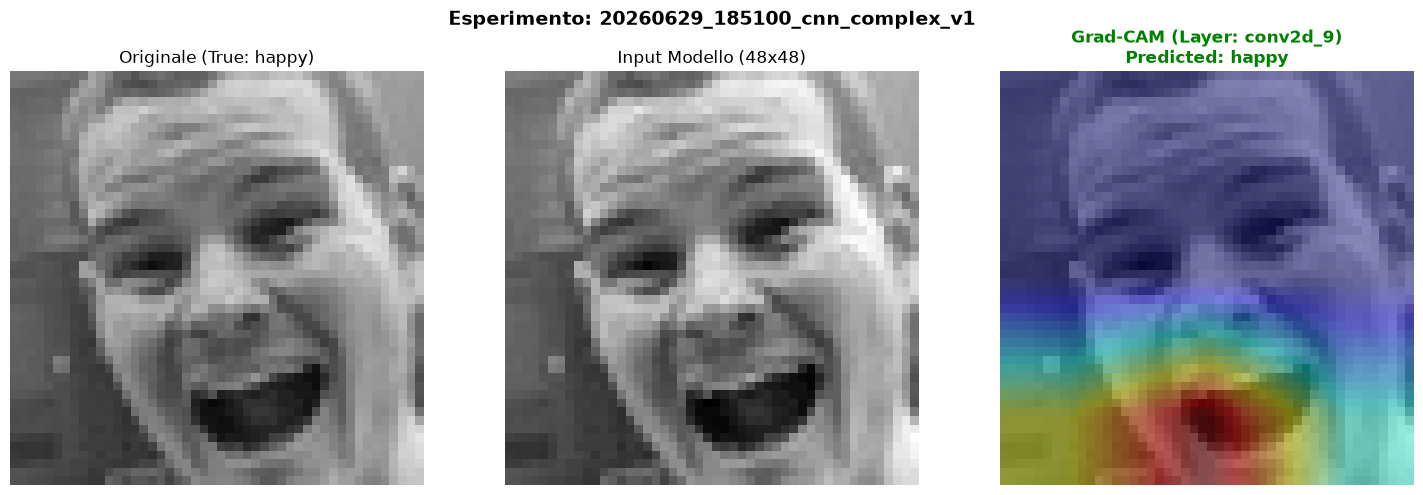


[ELABORAZIONE] Elaboro il modello: 20260705_190109_mobilenetv2_transfer
 -> Layer selezionato per Grad-CAM: 'out_relu' (Nidificato: True)


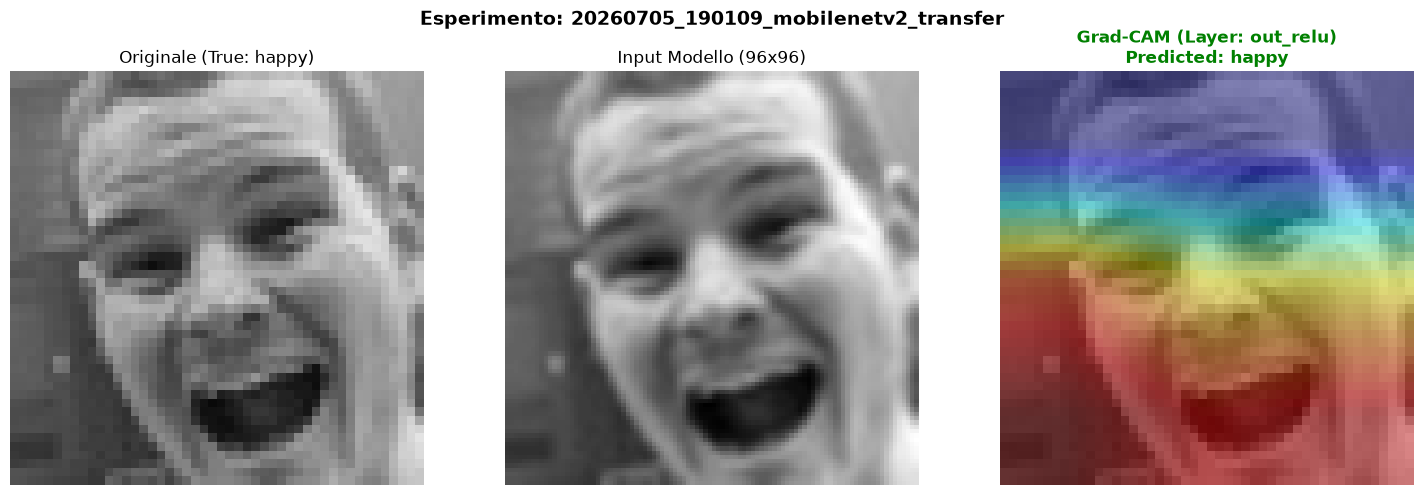


[ELABORAZIONE] Elaboro il modello: 20260705_194905_cnn_complex_v1
 -> Layer selezionato per Grad-CAM: 'conv2d_9' (Nidificato: False)


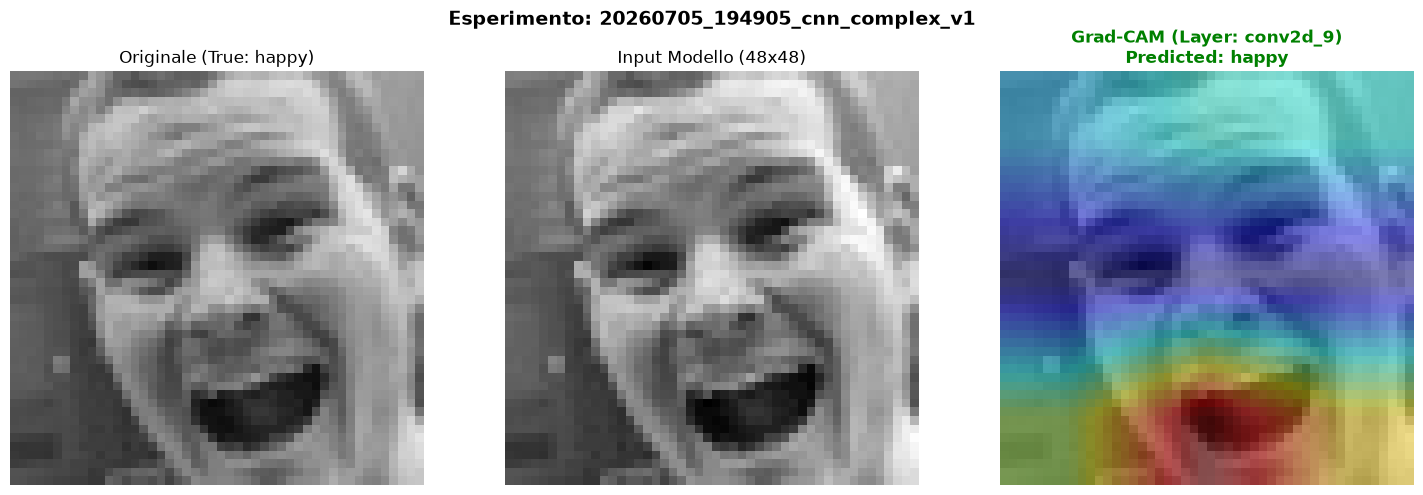


[ELABORAZIONE] Elaboro il modello: 20260705_201240_ResNet50_transfer
 -> Layer selezionato per Grad-CAM: 'conv5_block3_out' (Nidificato: True)


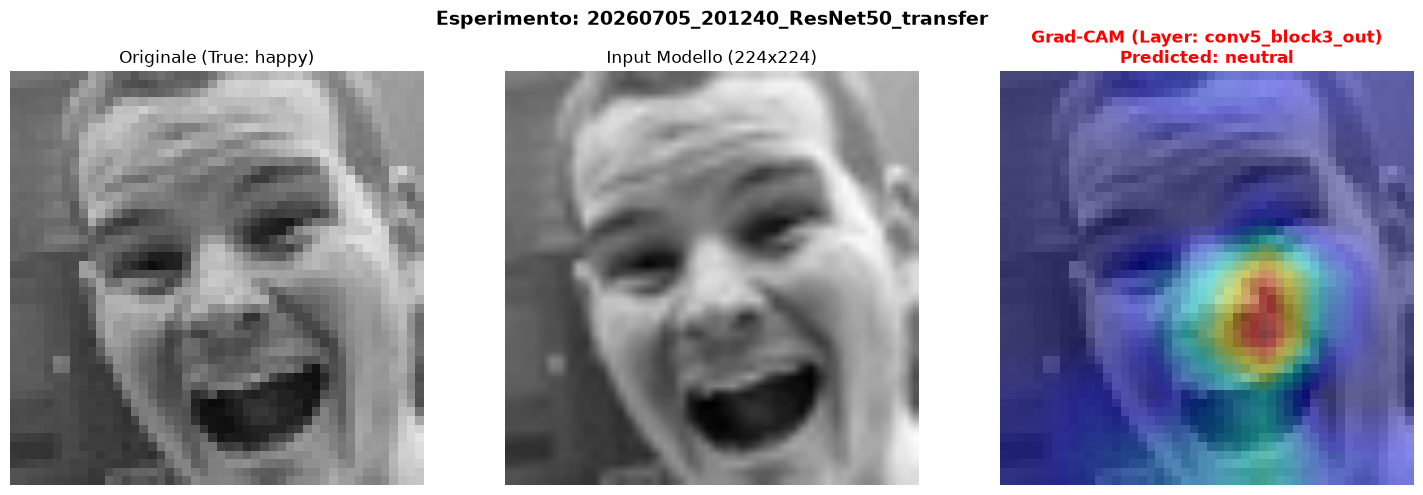


[ELABORAZIONE] Elaboro il modello: 20260705_201724_cnn_complex_v1
 -> Layer selezionato per Grad-CAM: 'conv2d_19' (Nidificato: False)


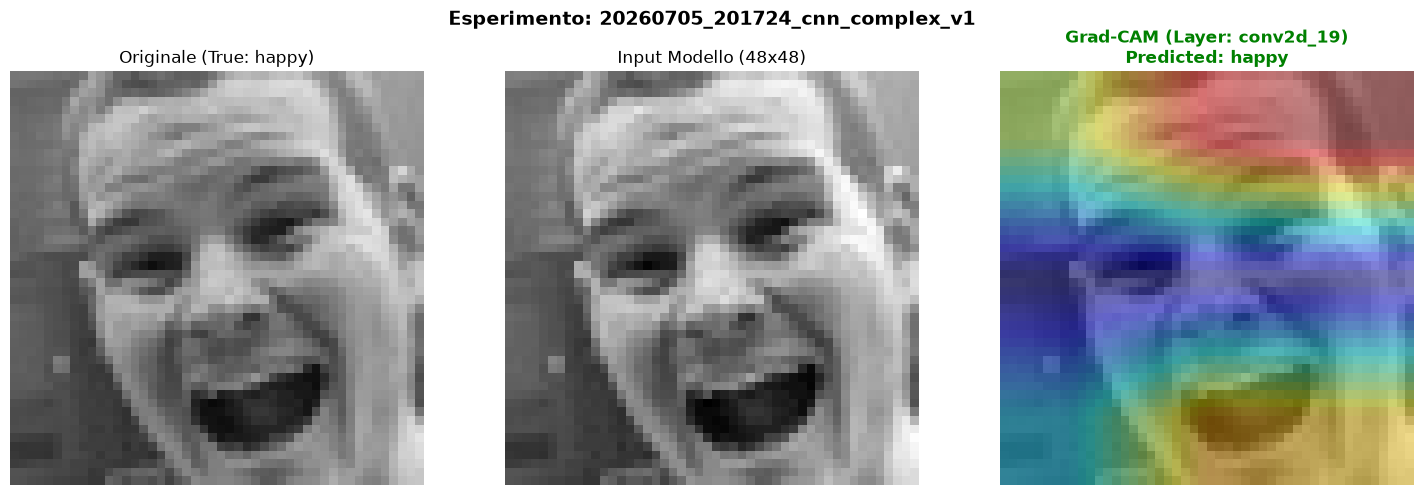


[ELABORAZIONE] Elaboro il modello: 20260706_063423_ResNet50_transfer
 -> Layer selezionato per Grad-CAM: 'conv5_block3_out' (Nidificato: True)


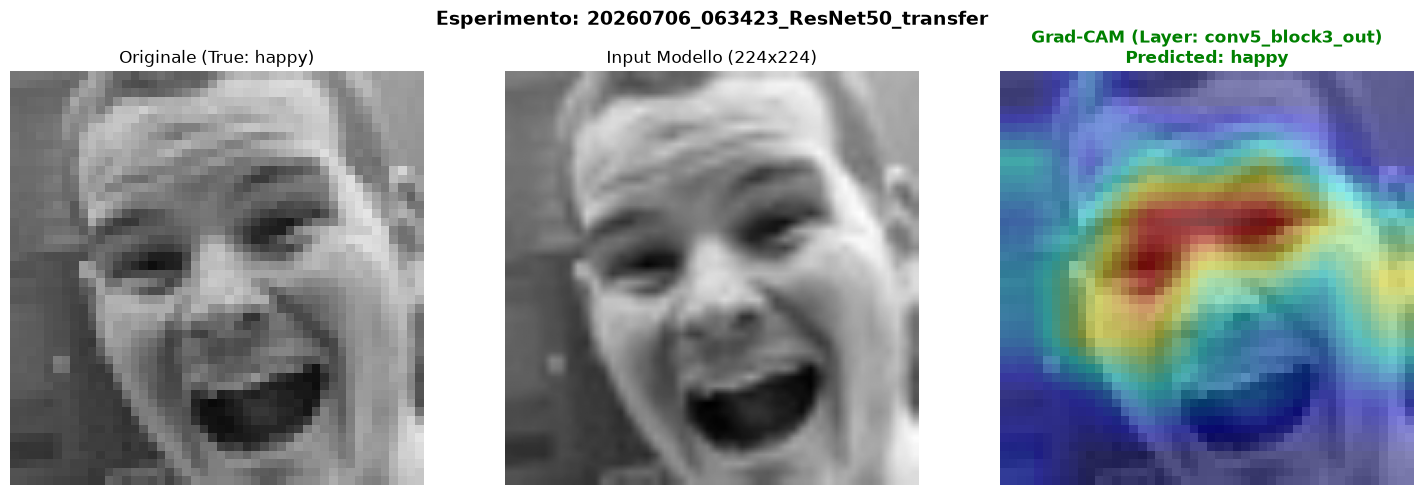


[ELABORAZIONE] Elaboro il modello: 20260706_172701_cnn_v2
 -> Layer selezionato per Grad-CAM: 'conv2d_20' (Nidificato: False)


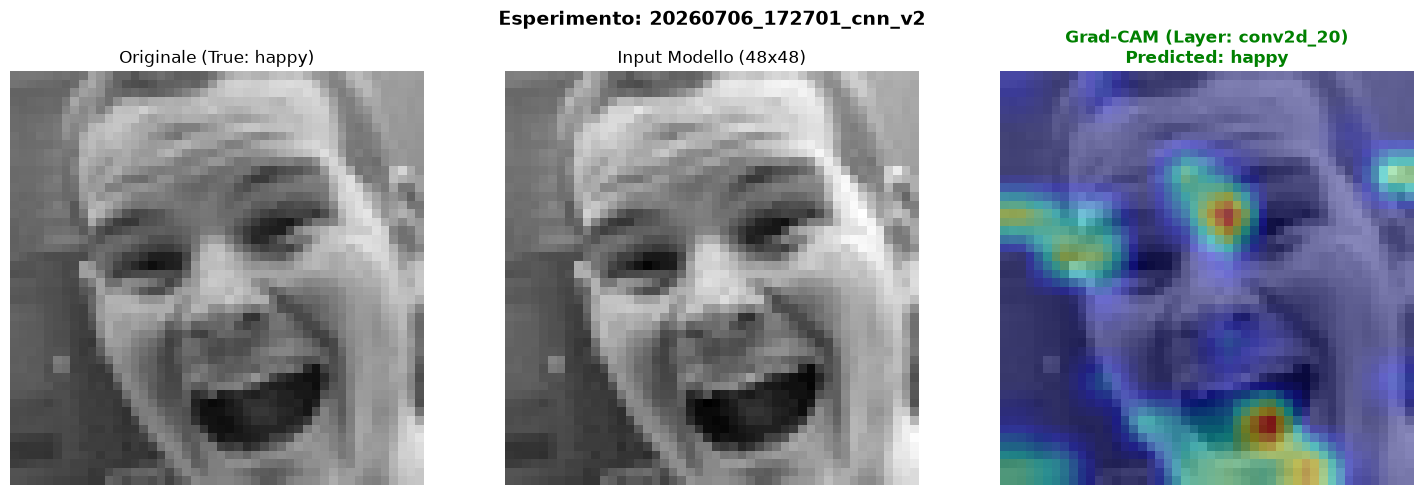


[ELABORAZIONE] Elaboro il modello: 20260706_174342_cnn_v3
 -> Layer selezionato per Grad-CAM: 'conv2d_3' (Nidificato: False)


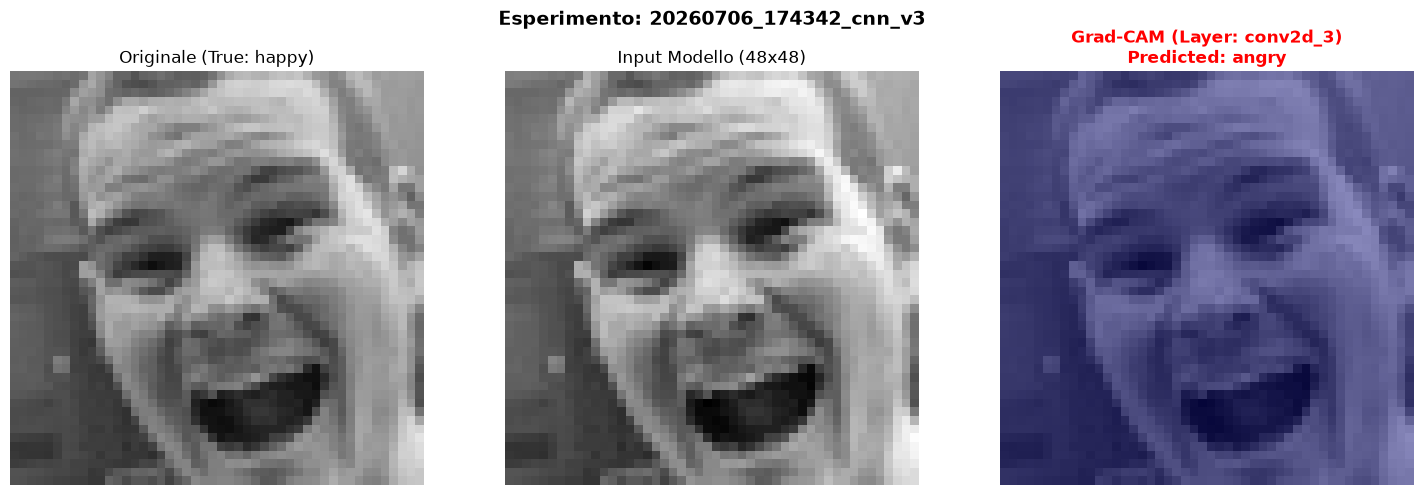


[ELABORAZIONE] Elaboro il modello: 20260706_175311_cnn_v4
 -> Layer selezionato per Grad-CAM: 'conv2d_11' (Nidificato: False)


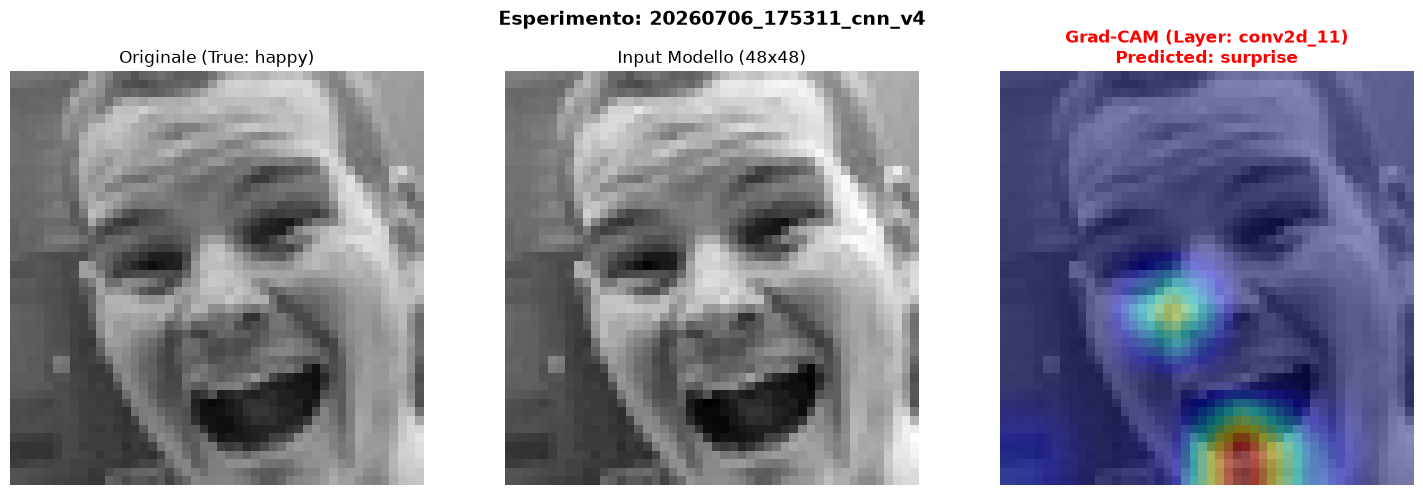


[ELABORAZIONE] Elaboro il modello: 20260706_232452_cnn_v3
 -> Layer selezionato per Grad-CAM: 'conv2d_10' (Nidificato: False)


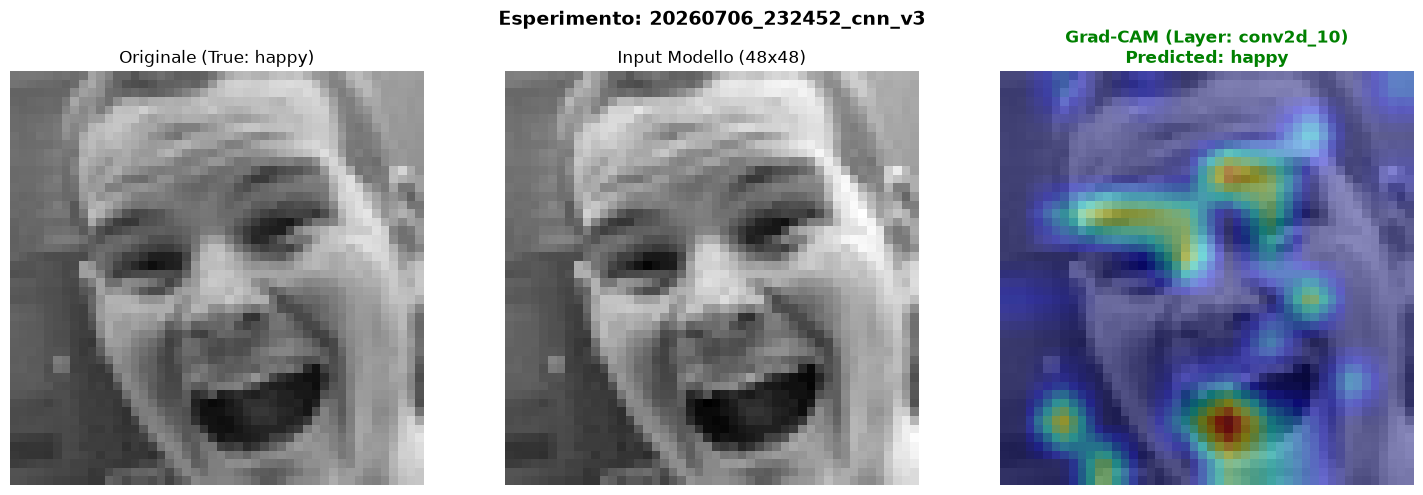


[ELABORAZIONE] Elaboro il modello: 20260706_233427_cnn_v4
 -> Layer selezionato per Grad-CAM: 'conv2d_7' (Nidificato: False)


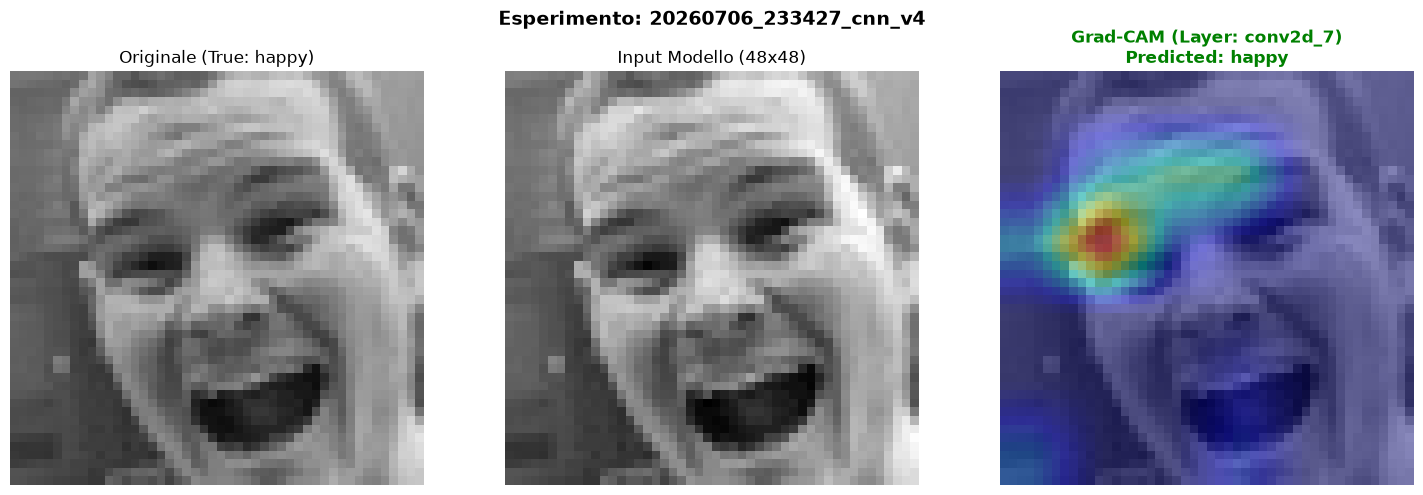


[COMPLETATO] Tutti i modelli sono stati elaborati e salvati in gradcam_results!


In [7]:
# --- 3. LOOP SU TUTTI I MODELLI IN EXPERIMENTS ---
experiment_dirs = []
for run_day in sorted(os.listdir(PATH_EXPERIMENTS)):
    day_dir = os.path.join(PATH_EXPERIMENTS, run_day)
    if not os.path.isdir(day_dir):
        continue
    for run_name in sorted(os.listdir(day_dir)):
        run_dir = os.path.join(day_dir, run_name)
        if os.path.isdir(run_dir):
            experiment_dirs.append(run_dir)

for path_modello_dir in experiment_dirs:
    cartella_esperimento = os.path.basename(path_modello_dir)

    # Definiamo i nomi dei file che vogliamo cercare
    nomi_modelli_cercati = ['model.keras', 'model_test.keras'] #Eliminare questo e il ciclo for nel caso si uniformino i nomi dei modelli salvati
    
    for nome_file_modello in nomi_modelli_cercati:
        path_model_keras = os.path.join(path_modello_dir, nome_file_modello)
    
        if os.path.exists(path_model_keras):
            print(f"\n[ELABORAZIONE] Elaboro il modello: {cartella_esperimento}")
            
            try:
                keras.backend.clear_session()
                model = keras.models.load_model(path_model_keras)
                
                # --- PREPARAZIONE CANALI INPUT E RIDIMENSIONAMENTO DINAMICO ---
                input_shape = model.input_shape  
                req_altezza = input_shape[1]
                req_larghezza = input_shape[2]
                req_canali = input_shape[3]

                # 1. Resize geometrico
                if req_altezza != 48 or req_larghezza != 48:
                    img_rescaled = cv2.resize(img_proc, (req_larghezza, req_altezza), interpolation=cv2.INTER_LINEAR)
                    img_proc_input_eval = img_rescaled.astype("float32") / 255.0
                    img_proc_input_eval = np.expand_dims(np.expand_dims(img_proc_input_eval, axis=-1), axis=0)
                else:
                    img_proc_input_eval = img_proc_input

                # 2. Controllo Canali (Es. Grayscale -> RGB per Transfer Learning)
                if req_canali == 3 and img_proc_input_eval.shape[-1] == 1:
                    current_input = np.repeat(img_proc_input_eval, 3, axis=-1)
                else:
                    current_input = img_proc_input_eval

                current_input_tensor = tf.convert_to_tensor(current_input, dtype=tf.float32)

                # Chiamata fittizia di inizializzazione nodi
                _ = model(current_input_tensor)
                
                # --- IDENTIFICAZIONE DEL LAYER TARGET E DELLA STRUTTURA ---
                target_layer_name = None
                is_nested_model = False
                nested_model_layer = None
                
                # Scansione dinamica per trovare l'ultimo layer convoluzionale o di attivazione utile
                for layer in reversed(model.layers):
                    if isinstance(layer, keras.models.Model) or hasattr(layer, 'layers'):
                        for sub_layer in reversed(layer.layers):
                            if "conv" in sub_layer.name or "relu" in sub_layer.name:
                                target_layer_name = sub_layer.name
                                is_nested_model = True
                                nested_model_layer = layer
                                break
                    elif "conv" in layer.name or "relu" in layer.name:
                        target_layer_name = layer.name
                    
                    if target_layer_name is not None:
                        break
                
                if target_layer_name is None:
                    print(f" -> Impossibile trovare un layer convoluzionale valido. Salto.")
                    continue
                    
                print(f" -> Layer selezionato per Grad-CAM: '{target_layer_name}' (Nidificato: {is_nested_model})")

                # --- APPLICAZIONE METODO FUSO ---
                cam, class_index = get_gradcam_heatmap(
                    current_input_tensor, model, target_layer_name, is_nested_model, nested_model_layer
                )
                
                # --- CREAZIONE OVERLAY VISIVO ---
                heatmap_resized = cv2.resize(cam, (larghezza_orig, altezza_orig))
                heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
                heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
                
                overlay = cv2.addWeighted(img_originale_rgb, 0.6, heatmap_color, 0.4, 0)
                classe_pred = CLASSI[class_index]
                
                # --- CREAZIONE DEL PLOT E VISUALIZZAZIONE ---
                fig, axes = plt.subplots(1, 3, figsize=(15, 5))
                
                axes[0].imshow(img_originale_rgb)
                axes[0].set_title(f"Originale (True: {NOME_CLASSE})")
                axes[0].axis("off")
                
                img_proc_visualizza = cv2.resize(img_proc, (req_larghezza, req_altezza), interpolation=cv2.INTER_LINEAR)
                axes[1].imshow(img_proc_visualizza, cmap="gray")
                axes[1].set_title(f"Input Modello ({req_larghezza}x{req_altezza})")
                axes[1].axis("off")
                
                axes[2].imshow(overlay)
                title_color = "green" if NOME_CLASSE == classe_pred else "red"
                axes[2].set_title(f"Grad-CAM (Layer: {target_layer_name})\nPredicted: {classe_pred}", color=title_color, fontweight="bold")
                axes[2].axis("off")
                
                plt.suptitle(f"Esperimento: {cartella_esperimento}", fontsize=14, fontweight='bold')
                plt.tight_layout()
                
                # Salvataggio automatico facoltativo del plot combinato
                output_file_path = os.path.join(PATH_OUTPUT_PLOT, f"gradcam_{cartella_esperimento}.png")
                plt.savefig(output_file_path, bbox_inches='tight', dpi=150)
                
                plt.show()
                
            except Exception as e:
                print(f" -> Errore durante l'elaborazione di {cartella_esperimento}: {e}")
            
print("\n[COMPLETATO] Tutti i modelli sono stati elaborati e salvati in gradcam_results!")